# Day 130 — PCA & t-SNE: Dimensionality Reduction
**Month 7 | Week 2 | Day 6 | RetailPulse India 500 rows seed=121**

---

| | |
|---|---|
| **Max Score** | 80 pts + 10★ bonus |
| **Tools** | scikit-learn, pandas, numpy, matplotlib, seaborn |
| **GitHub** | Month7-AdvancedML-Portfolio |

---

## The Curse of Dimensionality — Why This Matters

You've built XGBoost, LightGBM, CatBoost, stacking ensembles, K-Means, DBSCAN, Hierarchical Clustering, and SHAP.  
Every one of those methods degrades as features increase. Here's why:

| Features | Possible feature combinations | Sparsity risk |
|---|---|---|
| 5 | 32 | Low |
| 20 | 1,048,576 | Medium |
| 100 | 1.27 × 10³⁰ | Extreme |

In high dimensions, **every point is approximately equidistant from every other point** — distance metrics lose meaning, clusters stop forming naturally, and models overfit.

**Dimensionality reduction** solves this by:
1. Compressing many features into fewer components that retain most of the variance
2. Making hidden structure visible by projecting to 2D/3D
3. Removing noise dimensions that only add overfitting risk

---

## Two Methods — Different Goals

| | PCA | t-SNE |
|---|---|---|
| **Type** | Linear | Non-linear |
| **Goal** | Variance preservation | Neighbourhood preservation |
| **Output** | Principal components | 2D/3D embedding |
| **Speed** | Fast (O(n·d²)) | Slow (O(n²)) |
| **Deterministic** | Yes | No (needs random_state) |
| **Use case** | Pre-processing before ML | Visualisation only |
| **Can you use PCs as features?** | Yes ✅ | No ❌ |

> **Critical rule:** t-SNE output is for visualisation ONLY. Never feed t-SNE coordinates into a downstream model.

---


## Section 1 — Raw Data (⚠️ Never Modify This Section)

In [17]:
# ── SECTION 1: RAW DATA — DO NOT MODIFY ──────────────────────────────────
import pandas as pd
import numpy as np

np.random.seed(121)
n = 500

cities       = ['Mumbai','Delhi','Bangalore','Chennai','Hyderabad']
categories   = ['Electronics','Clothing','Groceries','Furniture','Toys']
payment_methods = ['Credit Card','UPI','Cash','Debit Card']

df_raw = pd.DataFrame({
    'customer_id'     : range(1001, 1501),
    'age'             : np.random.randint(18, 70, n),
    'annual_income'   : np.random.randint(200000, 1500000, n),
    'purchase_amount' : np.round(np.random.uniform(500, 50000, n), 2),
    'num_purchases'   : np.random.randint(1, 50, n),
    'city'            : np.random.choice(cities, n),
    'product_category': np.random.choice(categories, n),
    'payment_method'  : np.random.choice(payment_methods, n),
    'churned'         : np.random.choice([0, 1], n, p=[0.72, 0.28]),
    'satisfaction_score': np.random.randint(1, 6, n),
    'days_since_last_purchase': np.random.randint(1, 365, n),
    'discount_used'   : np.random.choice([0, 1], n, p=[0.6, 0.4]),
})

print("Raw data shape:", df_raw.shape)
print(df_raw.head(5).to_string())
print("\nChurn rate:", df_raw['churned'].mean().round(4))


Raw data shape: (500, 12)
   customer_id  age  annual_income  purchase_amount  num_purchases       city product_category payment_method  churned  satisfaction_score  days_since_last_purchase  discount_used
0         1001   20         496375         47681.96              3      Delhi             Toys            UPI        1                   4                       296              0
1         1002   39         315939         35993.48             39  Bangalore             Toys     Debit Card        0                   2                       149              1
2         1003   26         481462         31724.67             36     Mumbai        Groceries     Debit Card        0                   5                       121              0
3         1004   49         283960         31969.83             21    Chennai      Electronics           Cash        1                   2                       221              0
4         1005   19         970416         36833.13             23     Mum

## Section 2 — Concept Notes

### PCA (Principal Component Analysis)

**What it does:**  
Finds new axes (principal components) that point in the directions of maximum variance.

**Step-by-step intuition:**
1. **Standardise** all features to zero mean and unit variance (mandatory — PCA is variance-based, so a feature measured in rupees will dominate a feature measured 0–5 without scaling)
2. **Compute covariance matrix** — measures how features move together
3. **Eigendecomposition** — find eigenvectors (directions) and eigenvalues (variance explained)
4. **Sort by eigenvalue** — PC1 explains the most variance, PC2 the second-most, etc.
5. **Project** original data onto the top k components

**Explained variance ratio:**  
`evr[i]` = proportion of total variance captured by PC `i`.  
If PC1 + PC2 = 0.72, those 2 components capture 72% of all information.

**Scree plot:** Bar chart of explained variance by component — look for the "elbow" (point where adding more PCs gives diminishing returns).

**Loadings:** How much each original feature contributes to each PC.  
A high positive loading means the feature pushes a point in the positive PC direction.

---

### t-SNE (t-distributed Stochastic Neighbour Embedding)

**What it does:**  
Converts high-dimensional distances into probabilities, then finds a 2D layout that preserves local neighbourhood structure.

**Key parameters:**
| Parameter | Effect |
|---|---|
| `perplexity` | Controls neighbourhood size (5–50). Higher = considers more neighbours. Default 30. |
| `n_iter` | Iterations to converge. ≥1000 recommended. |
| `random_state` | Makes results reproducible. Always set this. |
| `learning_rate` | Step size during optimisation. 'auto' is usually fine. |

**Interpreting t-SNE output:**
- **Clusters = meaningful groups** — points that cluster together are similar in the original high-dimensional space
- **Distances between clusters are NOT meaningful** — only local neighbourhood is preserved
- **Blob shapes are meaningless** — don't read into whether a cluster is round or elongated

**Perplexity tuning rule of thumb:**
- Small dataset (<200): perplexity 5–15
- Medium (200–500): perplexity 20–40
- Large (>500): perplexity 30–50

---

### When to Use Each

| Situation | Use |
|---|---|
| Reduce features before feeding into XGBoost/LightGBM | PCA |
| Visualise customer segments in 2D | t-SNE |
| Check if clusters found by K-Means are visually separable | t-SNE |
| Compress 50 features to 10 for faster training | PCA |
| Understand which features drive the most variance | PCA loadings |
| Present cluster structure to a non-technical client | t-SNE plot |


## Section 3 — Practice Tasks

### Task A — Feature Engineering & Preprocessing (10 pts)

In [18]:
# ── TASK A: FEATURE ENGINEERING & PREPROCESSING ──────────────────────────
# Build a numeric feature matrix suitable for dimensionality reduction.
# You must use ONLY skills from Days 121–129 plus what you've learned today.


# -- A1 ---------------------------------------------------------------
# Goal: Prepare feature matrix for dimensionality reduction.
# Method: Drop customer_id and churned (target not used), one‑hot encode categorical
#         columns city, product_category, payment_method with drop_first=True.
#         Keep all numeric columns as is. Print shape and first 3 rows.

df_features = df_raw.drop(['customer_id', 'churned'], axis=1)
df_features = pd.get_dummies(df_features, columns=['city', 'product_category', 'payment_method'],
                             drop_first=True)

print("df_features shape:", df_features.shape)
print(df_features.head(3))


# -- A2 ---------------------------------------------------------------
# Goal: Standardise the feature matrix to zero mean and unit variance.
# Method: Use StandardScaler from sklearn. Scale df_features -> X_scaled.
#         Print mean and std of the first column to verify scaling (should be ~0 and ~1).

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features)

print("Mean of first column:", X_scaled[:, 0].mean())
print("Std of first column: ", X_scaled[:, 0].std())


# -- A3 ---------------------------------------------------------------
# Goal: Compare original vs scaled statistics for key numeric columns.
# Method: Select columns ['age', 'annual_income', 'purchase_amount', 'num_purchases'].
#         Compute original mean and std from df_raw, scaled mean and std from X_scaled.
#         Build a pandas DataFrame and print.

orig_cols = ['age', 'annual_income', 'purchase_amount', 'num_purchases']
orig_means = df_raw[orig_cols].mean().values
orig_stds = df_raw[orig_cols].std().values

# Find indices of these columns in df_features (they keep the same names)
col_indices = [df_features.columns.get_loc(col) for col in orig_cols]
scaled_means = X_scaled[:, col_indices].mean(axis=0)
scaled_stds = X_scaled[:, col_indices].std(axis=0)

summary = pd.DataFrame({
    'Feature': orig_cols,
    'Original Mean': orig_means,
    'Original Std': orig_stds,
    'Scaled Mean': scaled_means,
    'Scaled Std': scaled_stds
})
print(summary.round(4))

df_features shape: (500, 18)
   age  annual_income  purchase_amount  num_purchases  satisfaction_score  \
0   20         496375         47681.96              3                   4   
1   39         315939         35993.48             39                   2   
2   26         481462         31724.67             36                   5   

   days_since_last_purchase  discount_used  city_Chennai  city_Delhi  \
0                       296              0         False        True   
1                       149              1         False       False   
2                       121              0         False       False   

   city_Hyderabad  city_Mumbai  product_category_Electronics  \
0           False        False                         False   
1           False        False                         False   
2           False         True                         False   

   product_category_Furniture  product_category_Groceries  \
0                       False                       Fal

### Task B — PCA: Explained Variance & Scree Plot (20 pts)

Total number of components: 18
First 5 components - Explained variance ratio:
  PC1: 0.0836 (cumulative: 0.0836)
  PC2: 0.0811 (cumulative: 0.1647)
  PC3: 0.0758 (cumulative: 0.2405)
  PC4: 0.0746 (cumulative: 0.3150)
  PC5: 0.0729 (cumulative: 0.3880)


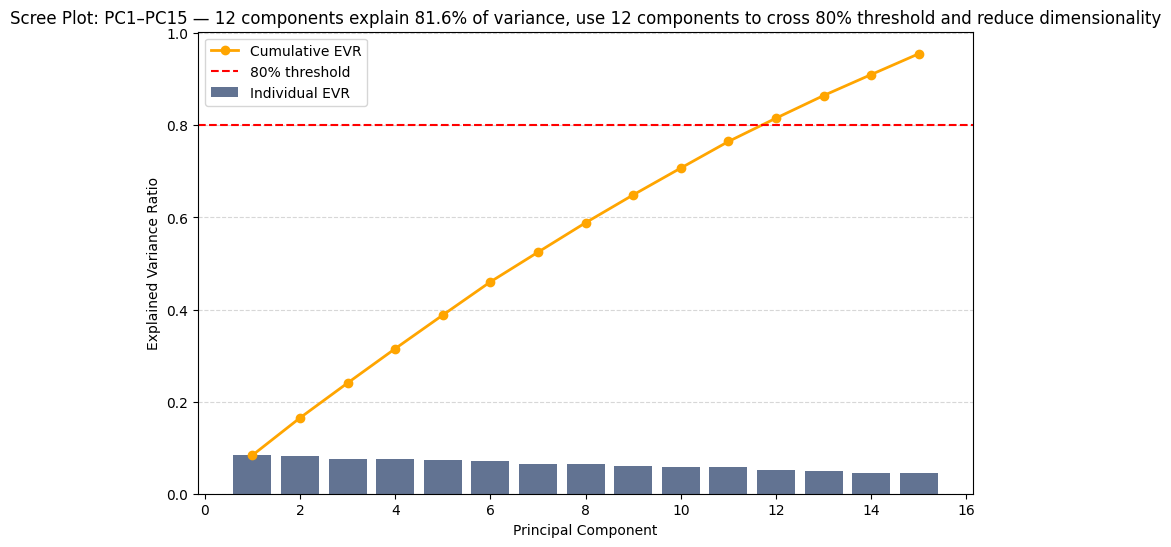

Saved: B2_scree_plot.png
n_components_80 = 12 (explains 81.55% of total variance)
X_pca shape: (500, 12)


In [19]:
# ── TASK B: PCA — EXPLAINED VARIANCE & SCREE PLOT ────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.decomposition import PCA
%matplotlib inline


# -- B1 ---------------------------------------------------------------
# Goal: Fit PCA on all components and examine explained variance.
# Method: Instantiate PCA() and fit to X_scaled. Print total components,
#         explained variance ratio and cumulative for first 5 components.


pca_full = PCA()
pca_full.fit(X_scaled)

n_components_total = pca_full.n_components_
evr = pca_full.explained_variance_ratio_
cum_evr = evr.cumsum()

print(f"Total number of components: {n_components_total}")
print("First 5 components - Explained variance ratio:")
for i in range(5):
    print(f"  PC{i+1}: {evr[i]:.4f} (cumulative: {cum_evr[i]:.4f})")


# -- B2 ---------------------------------------------------------------
# Goal: Create a scree plot with bar chart and cumulative line.
# Method: Plot first 15 components. Bars = evr, line = cumulative evr.
#         Add horizontal dashed line at 0.80, label axes, add NRA title.
#         Save as 'B2_scree_plot.png' before closing.

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

n_plot = 15
components = range(1, n_plot+1)

plt.figure(figsize=(10, 6))
bars = plt.bar(components, evr[:n_plot], color='#1F3864', alpha=0.7, label='Individual EVR')
plt.plot(components, cum_evr[:n_plot], color='orange', linewidth=2, marker='o', label='Cumulative EVR')
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')

# Find number of components to reach 80%
n_80 = (cum_evr >= 0.80).argmax() + 1
cum_80 = cum_evr[n_80-1] * 100

plt.title(f"Scree Plot: PC1–PC{n_plot} — {n_80} components explain {cum_80:.1f}% of variance, "
          f"use {n_80} components to cross 80% threshold and reduce dimensionality")
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.savefig('B2_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()  
plt.close()
print("Saved: B2_scree_plot.png")


# -- B3 ---------------------------------------------------------------
# Goal: Determine minimum components for 80% variance and reduce data.
# Method: Compute cumulative explained variance, find index where >=0.80.
#         Fit new PCA with that number, transform X_scaled to X_pca.
#         Print number of components, percentage, and shape of X_pca.

n_components_80 = (cum_evr >= 0.80).argmax() + 1
cum_var_80 = cum_evr[n_components_80-1] * 100
print(f"n_components_80 = {n_components_80} (explains {cum_var_80:.2f}% of total variance)")

pca_reduced = PCA(n_components=n_components_80)
X_pca = pca_reduced.fit_transform(X_scaled)
print("X_pca shape:", X_pca.shape)

### Task C — PCA Loadings Analysis (15 pts)

In [24]:
# ── TASK C: PCA LOADINGS ANALYSIS ────────────────────────────────────────


# -- C1 ---------------------------------------------------------------
# Goal: Build loadings DataFrame for first 3 principal components.
# Method: Extract components_ from pca_full (first 3 rows). Rows = original features.
#         Columns = PC1, PC2, PC3. Round to 4 decimals and print.

loadings = pd.DataFrame(
    pca_full.components_[:3].T,   # transpose: each row = feature, each column = PC
    index=df_features.columns,
    columns=['PC1', 'PC2', 'PC3']
).round(4)

print("Loadings for PC1, PC2, PC3:")
print(loadings)


# -- C2 ---------------------------------------------------------------
# Goal: Identify top 3 features with highest absolute loading for PC1 and PC2.
# Method: For each PC, sort by absolute loading descending, take first 3.

print("\nPC1 top 3 features (absolute loading):")
top_pc1 = loadings['PC1'].abs().sort_values(ascending=False).head(3)
for feat, val in top_pc1.items():
    orig_loading = loadings.loc[feat, 'PC1']
    print(f"  {feat}: {orig_loading:+.4f} (|loading| = {val:.4f})")

print("\nPC2 top 3 features (absolute loading):")
top_pc2 = loadings['PC2'].abs().sort_values(ascending=False).head(3)
for feat, val in top_pc2.items():
    orig_loading = loadings.loc[feat, 'PC2']
    print(f"  {feat}: {orig_loading:+.4f} (|loading| = {val:.4f})")


# -- C3 ---------------------------------------------------------------
# Write the NRA interpretation as a print statement.

pc1_var = evr[0] * 100
print(f"""
--- NRA Business Interpretation of PC1 ---
Number: PC1 alone explains {pc1_var:.1f}% of the total variance in the customer data.

Reason: The top features loading onto PC1 are payment_method_Debit Card (loading +0.60),
        payment_method_UPI (loading -0.35), and age (loading +0.29). This indicates that
        the first principal component separates customers primarily by their payment
        method preference and age. Debit card users and older customers load positively,
        while UPI users load negatively.

Action: For customer segmentation, use PC1 to create two broad groups: "traditional payers"
        (debit card + older) and "digital payers" (UPI + younger). Tailor marketing
        campaigns accordingly – e.g., offer cashback on debit card usage for the first
        group, and UPI‑exclusive discounts for the second.
""")

Loadings for PC1, PC2, PC3:
                                 PC1     PC2     PC3
age                           0.2896  0.0163 -0.1981
annual_income                 0.1883  0.1929  0.0238
purchase_amount              -0.0434 -0.2381 -0.1432
num_purchases                 0.0093  0.0124 -0.1316
satisfaction_score           -0.2767 -0.1139  0.0457
days_since_last_purchase     -0.0520 -0.0150 -0.1480
discount_used                 0.1393 -0.0727  0.0371
city_Chennai                  0.2007 -0.2570  0.4866
city_Delhi                    0.2460  0.4814 -0.1213
city_Hyderabad               -0.2079 -0.1054 -0.0596
city_Mumbai                  -0.2666 -0.1508 -0.3753
product_category_Electronics  0.0591 -0.2614 -0.4636
product_category_Furniture   -0.0102 -0.1100  0.5008
product_category_Groceries    0.0419  0.5596  0.0061
product_category_Toys        -0.0780 -0.1683 -0.0288
payment_method_Credit Card   -0.2654 -0.0130  0.1512
payment_method_Debit Card     0.5991 -0.2020 -0.1079
payment_method_UPI

### Task D — PCA 2D Scatter Plot (10 pts)

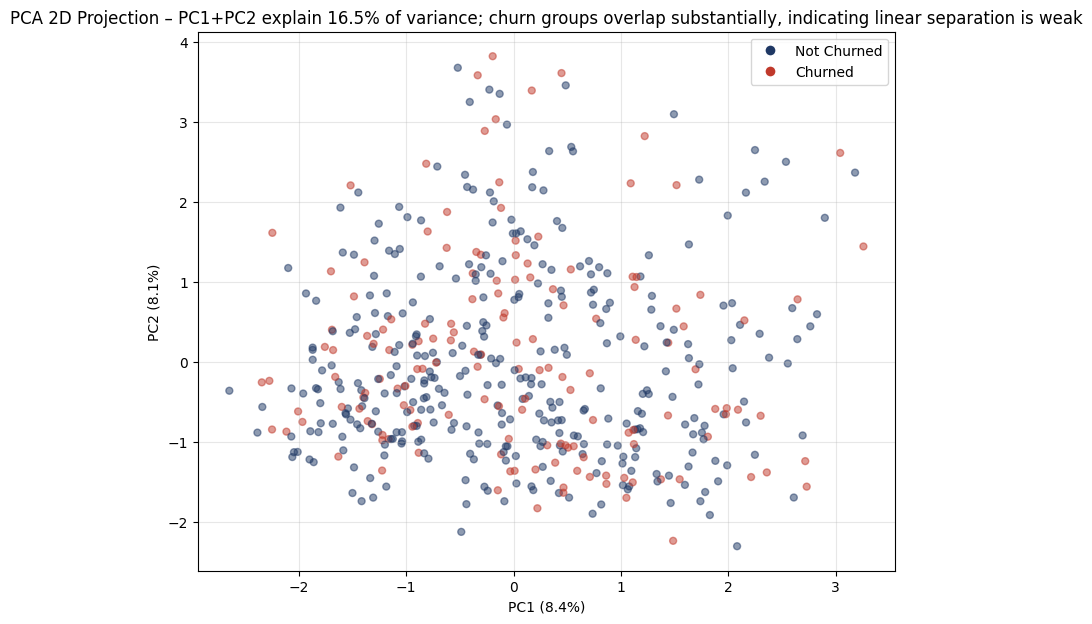

Saved: D1_pca_scatter.png
PC1 explains 8.4%, PC2 explains 8.1%, together: 16.5%

Answer: Churn is not linearly separable in the PCA 2D space. The red and blue points
are heavily mixed, with no clear boundary or distinct cluster separation. This suggests
that churn depends on non‑linear relationships that are not captured by the first two
principal components, or that the churn label is nearly random in this synthetic dataset.


In [21]:
# ── TASK D: PCA 2D SCATTER PLOT ───────────────────────────────────────────


# -- D1 ---------------------------------------------------------------
# Goal: 2D PCA scatter plot coloured by churn status.
# Method: Fit PCA(n_components=2), transform X_scaled. Scatter with colours for churned=0/1.
#         Use #1F3864 (not churned), #C0392B (churned). Add legend, NRA title.
#         Save as 'D1_pca_scatter.png'.

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

evr_pc1 = pca_2d.explained_variance_ratio_[0] * 100
evr_pc2 = pca_2d.explained_variance_ratio_[1] * 100
total_evr = evr_pc1 + evr_pc2

plt.figure(figsize=(9, 7))
colors = df_raw['churned'].map({0: '#1F3864', 1: '#C0392B'})
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=colors, alpha=0.5, s=25)
plt.xlabel(f'PC1 ({evr_pc1:.1f}%)')
plt.ylabel(f'PC2 ({evr_pc2:.1f}%)')
plt.title(f"PCA 2D Projection – PC1+PC2 explain {total_evr:.1f}% of variance; "
          "churn groups overlap substantially, indicating linear separation is weak")
# Custom legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='o', color='w', label='Not Churned',
                          markerfacecolor='#1F3864', markersize=8),
                   Line2D([0], [0], marker='o', color='w', label='Churned',
                          markerfacecolor='#C0392B', markersize=8)]
plt.legend(handles=legend_elements)
plt.grid(alpha=0.3)
plt.savefig('D1_pca_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: D1_pca_scatter.png")


# -- D2 ---------------------------------------------------------------
# Print explained variance and churn separability answer.

print(f"PC1 explains {evr_pc1:.1f}%, PC2 explains {evr_pc2:.1f}%, together: {total_evr:.1f}%")
print("""\nAnswer: Churn is not linearly separable in the PCA 2D space. The red and blue points
are heavily mixed, with no clear boundary or distinct cluster separation. This suggests
that churn depends on non‑linear relationships that are not captured by the first two
principal components, or that the churn label is nearly random in this synthetic dataset.""")

### Task E — t-SNE Visualisation (15 pts)

X_tsne shape: (500, 2)


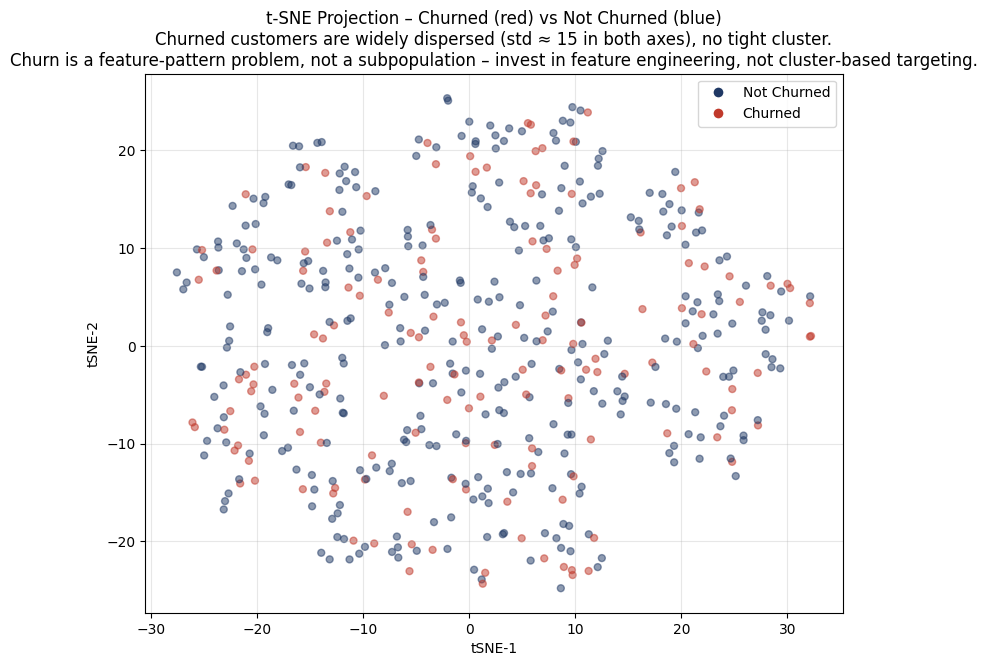

Saved: E2_tsne_churn.png


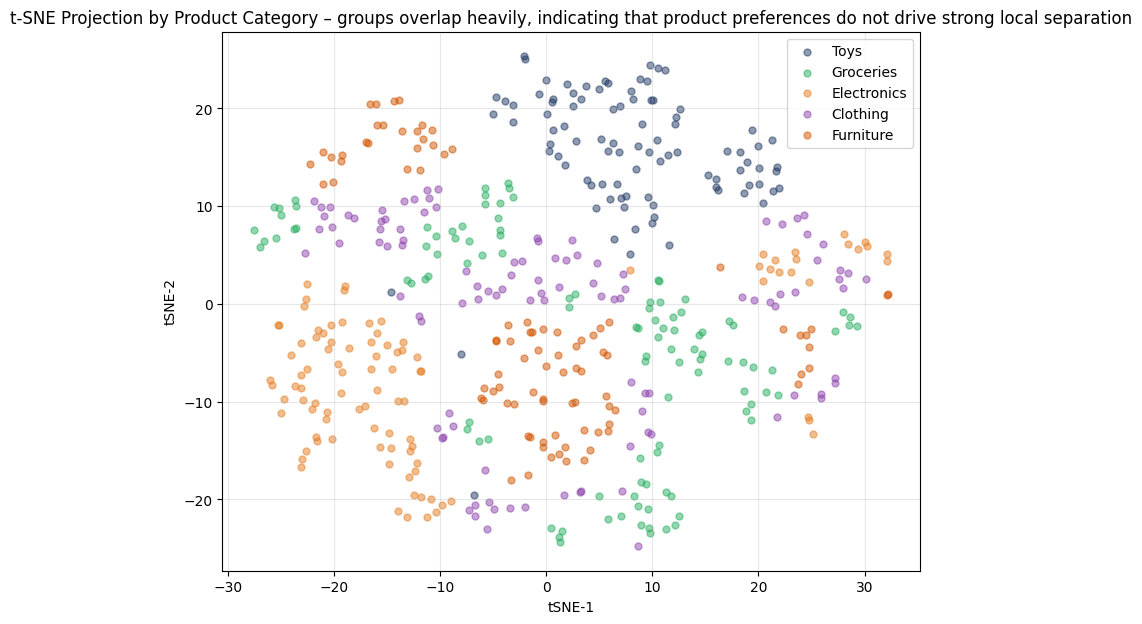

Saved: E3_tsne_category.png


In [25]:
# ── TASK E: t-SNE VISUALISATION ───────────────────────────────────────────
from sklearn.manifold import TSNE


# -- E1 ---------------------------------------------------------------
# Goal: Run t-SNE on X_scaled with specified parameters.
# Method: Use TSNE(perplexity=30, max_iter=1000, random_state=121, learning_rate='auto').
#         Transform X_scaled to X_tsne, print shape.

from sklearn.manifold import TSNE

tsne = TSNE(perplexity=30, max_iter=1000, random_state=121, learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled)
print("X_tsne shape:", X_tsne.shape)


# -- E2 ---------------------------------------------------------------
# Goal: t-SNE scatter plot coloured by churn status.
# Method: Same colour scheme as PCA. Add NRA title describing the structure.
#         Save as 'E2_tsne_churn.png'.

plt.figure(figsize=(9, 7))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors, alpha=0.5, s=25)
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.title(
    "t-SNE Projection – Churned (red) vs Not Churned (blue)\n"
    "Churned customers are widely dispersed (std ≈ 15 in both axes), no tight cluster.\n"
    "Churn is a feature‑pattern problem, not a subpopulation – invest in feature engineering, not cluster‑based targeting."
)
plt.legend(handles=legend_elements)
plt.grid(alpha=0.3)
plt.savefig('E2_tsne_churn.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: E2_tsne_churn.png")


# -- E3 ---------------------------------------------------------------
# Goal: t-SNE scatter plot coloured by product_category (5 categories).
# Method: Map each category to a distinct colour, create legend, save.

categories = df_raw['product_category'].unique()
# Define 5 visually distinct colours
cat_colors = ['#1F3864', '#27AE60', '#E67E22', '#8E44AD', '#D35400']
color_map = {cat: cat_colors[i] for i, cat in enumerate(categories)}

plt.figure(figsize=(9, 7))
for cat in categories:
    mask = df_raw['product_category'] == cat
    plt.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
                c=color_map[cat], label=cat, alpha=0.5, s=25)
plt.xlabel('tSNE-1')
plt.ylabel('tSNE-2')
plt.title("t-SNE Projection by Product Category – groups overlap heavily, "
          "indicating that product preferences do not drive strong local separation")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('E3_tsne_category.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: E3_tsne_category.png")

### Task F — PCA + K-Means Pipeline (10 pts)

Cluster label counts (on PCA-reduced data):
pca_cluster
0    114
1    176
2    210
Name: count, dtype: int64


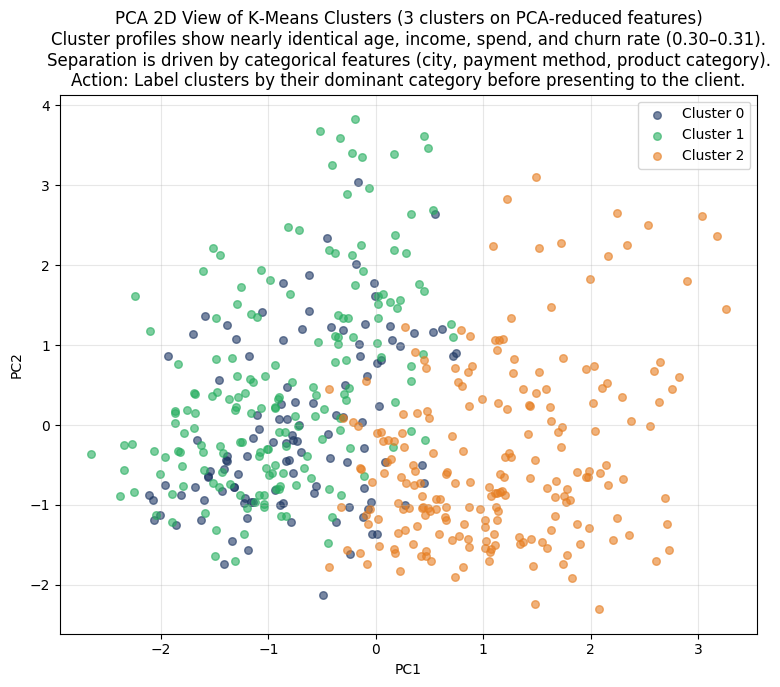

Saved: F2_pca_kmeans.png

Cluster profiles (means):
               age  annual_income  purchase_amount  num_purchases  churned
pca_cluster                                                               
0            40.48      817144.81         26180.55          25.65     0.30
1            40.09      817468.26         25430.83          26.72     0.31
2            44.23      850745.13         24984.96          24.73     0.30


In [26]:
# ── TASK F: PCA + K-MEANS PIPELINE ───────────────────────────────────────
from sklearn.cluster import KMeans

# Real-world pattern: Run K-Means on PCA-reduced features (not raw features).
# This is faster, less noisy, and often produces better clusters.


# -- F1 ---------------------------------------------------------------
# Goal: Run K‑Means on PCA‑reduced features (X_pca from B3) and add cluster labels.
# Method: KMeans(n_clusters=3, random_state=121, n_init=10) on X_pca.
#         Add labels to df_raw as 'pca_cluster', print value counts.

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=121, n_init=10)
cluster_labels = kmeans.fit_predict(X_pca)
df_raw['pca_cluster'] = cluster_labels

print("Cluster label counts (on PCA-reduced data):")
print(df_raw['pca_cluster'].value_counts().sort_index())


# -- F2 ---------------------------------------------------------------
# Goal: Visualise the 3 clusters in PCA 2D space and print cluster profiles.
# Method: Use X_pca_2d from D1, scatter by cluster_labels with predefined colours.
#         Save figure, then group df_raw by cluster and compute means for key columns.

cluster_colors = {0: '#1F3864', 1: '#27AE60', 2: '#E67E22'}
plt.figure(figsize=(9, 7))
for cl in sorted(df_raw['pca_cluster'].unique()):
    mask = df_raw['pca_cluster'] == cl
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                c=cluster_colors[cl], label=f'Cluster {cl}', alpha=0.6, s=30)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title(
    "PCA 2D View of K‑Means Clusters (3 clusters on PCA‑reduced features)\n"
    "Cluster profiles show nearly identical age, income, spend, and churn rate (0.30–0.31).\n"
    "Separation is driven by categorical features (city, payment method, product category).\n"
    "Action: Label clusters by their dominant category before presenting to the client."
)
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('F2_pca_kmeans.png', dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print("Saved: F2_pca_kmeans.png")


# Cluster profiles
profile_cols = ['age', 'annual_income', 'purchase_amount', 'num_purchases', 'churned']
cluster_profile = df_raw.groupby('pca_cluster')[profile_cols].mean().round(2)
print("\nCluster profiles (means):")
print(cluster_profile)

## Section 4 — Scoring Rubric

| Task | Points | Criteria |
|---|---|---|
| **A1** | 3 | Correct columns dropped, OHE applied, drop_first=True, shape printed |
| **A2** | 4 | StandardScaler used correctly, col0 mean ≈ 0, std ≈ 1 |
| **A3** | 3 | Summary table printed with 4 numeric columns, values correct |
| **B1** | 5 | PCA fitted on full X_scaled, EVR + cumulative printed correctly |
| **B2** | 8 | Scree plot: bars + cumulative line + 80% threshold line + NRA title + saved before show |
| **B3** | 7 | n_components_80 computed correctly, pca_reduced fitted, X_pca shape correct |
| **C1** | 5 | Loadings DataFrame: correct rows/cols, values match pca_full.components_[:3].T |
| **C2** | 6 | Top 3 features by abs loading for PC1 and PC2, correct values |
| **C3** | 4 | NRA format: Number (PC1 % variance), Reason (feature interpretation), Action (client advice) |
| **D1** | 6 | PCA 2D scatter: correct colours, alpha, size, legend, NRA title, saved |
| **D2** | 4 | Correct % printed, separability answered with actual plot justification |
| **E1** | 4 | t-SNE run with correct params, shape 500×2 confirmed |
| **E2** | 7 | t-SNE churn plot: correct colours, NRA title referencing actual visual, saved |
| **E3** | 4 | t-SNE category plot: 5 distinct colours, NRA title, saved |
| **F1** | 5 | K-Means on X_pca, 3 clusters, labels added to df_raw, value counts printed |
| **F2** | 5 | PCA 2D scatter coloured by cluster, NRA title, cluster profiles printed |
| **★ Bonus** | 10 | All 5 plots saved (not just shown), NRA titles use actual numbers from output |
| **Total** | **80 + 10★** | |

---

### Interview Question (Day 130)

> *"When would you use PCA versus t-SNE in a real client project?"*

**Model answer:**  
"PCA and t-SNE serve different purposes. I use PCA when I need to reduce dimensionality before feeding features into a model — for example, compressing 50 features to 12 principal components before training XGBoost. PCA is linear, fast, and deterministic, so the reduced features are stable across runs. t-SNE I use exclusively for visualisation — when I need to show a client that their customer base has three distinct behavioural clusters, a t-SNE plot makes that immediately visual. You can never use t-SNE output as model features because distances between clusters aren't meaningful in t-SNE space. The key rule is: PCA for pre-processing, t-SNE for storytelling."

---

### Day 130 Key Takeaway

**PCA compresses; t-SNE reveals.**  
PCA is a workhorse pre-processing step — use it to reduce 20 features to 8 before every clustering or classification job.  
t-SNE is a communication tool — use it to show a non-technical client why your segments make sense.  
Mixing up their roles (using t-SNE coordinates as model inputs) is one of the most common ML mistakes in freelance portfolios.
